# 07 — Strategy Recommendation Engine

**Goal**: Generate data-driven bowling strategy, field placement, and matchup recommendations.

**All inputs are Full Name based — consistent across every notebook.**

**Functions**:
1. `get_batsman_threat(name, phase)` — threat level from phase stats
2. `recommend_bowling_strategy(batsman, phase, bowler_style)` — tactical plan
3. `suggest_field_placement(batsman, phase, bowler_style)` — 9 fielders
4. `full_matchup_report(...)` — combined report
5. `find_best_bowler_vs(batsman, squad)` — rank squad bowlers

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110})

## 1. Load Data

In [13]:
df           = pd.read_csv(os.path.join(DATA_DIR, 'final_processed_data.csv'))
profiles     = pd.read_csv(os.path.join(DATA_DIR, 'batsman_profiles.csv'))
phase_sr     = pd.read_csv(os.path.join(DATA_DIR, 'phase_sr.csv'))
bowler_stats = pd.read_csv(os.path.join(DATA_DIR, 'bowler_stats.csv'))
matchup_df   = pd.read_csv(os.path.join(DATA_DIR, 'bowling_success_model.csv'))

# Unified lowercase Full Name keys — no short codes anywhere
profiles['name_key'] = profiles['Full Name'].str.lower().str.strip()
phase_sr['name_key'] = phase_sr['Full Name'].str.lower().str.strip()

print("profiles    :", len(profiles))
print("phase_sr    :", len(phase_sr))
print("bowler_stats:", len(bowler_stats))
print("matchup_df  :", len(matchup_df))

# Sanity check
v = phase_sr[phase_sr['name_key'] == 'virat kohli']
print("Virat Kohli phases:", sorted(v['match_phase'].tolist()))

profiles    : 248
phase_sr    : 940
bowler_stats: 318
matchup_df  : 4936
Virat Kohli phases: ['Death', 'Middle', 'Powerplay']


## 2. Threat Assessment

In [14]:
def get_batsman_threat(batsman_name, phase='Middle'):
    """
    Classify batsman threat level in a phase.
    Uses phase_sr for SR, boundary_pct, adaptability_index.
    All columns sourced from phase_sr (produced by notebook 04).
    """
    key = batsman_name.lower().strip()

    phase_row = phase_sr[
        (phase_sr['name_key'].str.contains(key, na=False, regex=False)) &
        (phase_sr['match_phase'].str.lower() == phase.lower())
    ]
    prof_row = profiles[profiles['name_key'].str.contains(key, na=False, regex=False)]

    if phase_row.empty:
        return {'error': f"No phase data for '{batsman_name}' in {phase}."}

    sr       = float(phase_row['strike_rate'].iloc[0])
    bdry_pct = float(phase_row['boundary_pct'].iloc[0])
    adapt    = float(phase_row['adaptability_index'].iloc[0])
    cons     = (float(prof_row['consistency_index'].iloc[0])
                if not prof_row.empty and 'consistency_index' in prof_row.columns else 0.0)
    display  = (prof_row['Full Name'].iloc[0] if not prof_row.empty
                else phase_row['Full Name'].iloc[0])

    agg = (sr/200)*0.5 + (bdry_pct/50)*0.3 + adapt*0.2
    threat = ('High Threat' if agg>0.6 else ('Medium Threat' if agg>0.35 else 'Low Threat'))

    return {'batsman': display, 'phase': phase,
            'strike_rate': round(sr,1), 'boundary_pct': round(bdry_pct,1),
            'adaptability_index': round(adapt,3), 'consistency_index': round(cons,3),
            'aggressiveness': round(agg,3), 'threat_level': threat}

for name, phase in [('Virat Kohli','Middle'),('MS Dhoni','Death'),
                     ('Babar Azam','Powerplay'),('Rohit Sharma','Powerplay')]:
    r = get_batsman_threat(name, phase)
    if 'error' in r: print(f"  FAIL  {name}/{phase}: {r['error']}")
    else: print(f"  OK  {r['batsman']:22s}/{phase:10s}: SR={r['strike_rate']:6.1f}  {r['threat_level']}")

  OK  Virat Kohli           /Middle    : SR= 117.1  Medium Threat
  OK  MS Dhoni              /Death     : SR= 151.3  Medium Threat
  OK  Babar Azam            /Powerplay : SR=  88.7  Low Threat
  OK  Rohit Sharma          /Powerplay : SR= 117.2  Medium Threat


## 3. Bowling Strategy

In [15]:
STRATEGY_RULES = {
    ('High Threat','fast')  : {'line':'OUTSIDE_OFFSTUMP','length':'SHORT_OF_A_GOOD_LENGTH',
        'plan':'Back-of-a-length outside off. Bouncers to disrupt. Avoid full deliveries.'},
    ('High Threat','spin')  : {'line':'ON_THE_STUMPS','length':'FULL',
        'plan':'Flight and drift. Invite the drive. Mid-on and long-off deep.'},
    ('High Threat','medium'): {'line':'OUTSIDE_OFFSTUMP','length':'GOOD_LENGTH',
        'plan':'Off-stump channel with swing. No width. Mix cutters.'},
    ('Medium Threat','fast'): {'line':'ON_THE_STUMPS','length':'GOOD_LENGTH',
        'plan':'Good length on and outside off. Mix yorkers. Use slower balls.'},
    ('Medium Threat','spin'): {'line':'OUTSIDE_OFFSTUMP','length':'GOOD_LENGTH',
        'plan':'Disciplined off-stump line. Vary flight. Build pressure.'},
    ('Medium Threat','medium'):{'line':'OUTSIDE_OFFSTUMP','length':'FULL',
        'plan':'Full and swing. Slower cutters. Keep boundary riders set.'},
    ('Low Threat','fast')   : {'line':'ON_THE_STUMPS','length':'YORKER',
        'plan':'Attack with yorkers. Straight and full. Batsman under pressure.'},
    ('Low Threat','spin')   : {'line':'ON_THE_STUMPS','length':'FULL',
        'plan':'Toss it up. Attack with close catchers. Go for the wicket.'},
    ('Low Threat','medium') : {'line':'ON_THE_STUMPS','length':'GOOD_LENGTH',
        'plan':'Consistent lines. Build dot-ball pressure.'},
}
PHASE_NOTE = {
    'Powerplay':'  [PP] Keep fielders up; slip cordon; restrict boundaries.',
    'Middle'   :'  [Mid] Rotate bowlers; vary pace; build dot pressure.',
    'Death'    :'  [Death] Wide yorkers; all deep fielders back.'
}
def classify_bowler_type(style):
    s = style.lower()
    if 'fast' in s: return 'fast'
    if 'medium' in s: return 'medium'
    return 'spin'

def recommend_bowling_strategy(batsman_name, phase, bowler_bowling_style):
    threat = get_batsman_threat(batsman_name, phase)
    if 'error' in threat: return threat
    btype = classify_bowler_type(bowler_bowling_style)
    rule  = STRATEGY_RULES.get((threat['threat_level'], btype),
                                STRATEGY_RULES[('Medium Threat','medium')])
    plan  = rule['plan'] + PHASE_NOTE.get(phase.capitalize(),'')
    return {'batsman': threat['batsman'], 'phase': phase,
            'bowler_style': bowler_bowling_style,
            'strike_rate': threat['strike_rate'],
            'adaptability': threat['adaptability_index'],
            'threat_level': threat['threat_level'],
            'recommended_line': rule['line'],
            'recommended_length': rule['length'],
            'tactical_plan': plan}

for bat, ph, bwl in [('Virat Kohli','Middle','right-arm fast'),
                      ('MS Dhoni','Death','slow left-arm orthodox')]:
    rec = recommend_bowling_strategy(bat, ph, bwl)
    print(f"\n--- {rec['batsman']} / {ph} ---")
    for k,v in rec.items(): print(f"  {k:22s}: {v}")


--- Virat Kohli / Middle ---
  batsman               : Virat Kohli
  phase                 : Middle
  bowler_style          : right-arm fast
  strike_rate           : 117.1
  adaptability          : 0.313
  threat_level          : Medium Threat
  recommended_line      : ON_THE_STUMPS
  recommended_length    : GOOD_LENGTH
  tactical_plan         : Good length on and outside off. Mix yorkers. Use slower balls.  [Mid] Rotate bowlers; vary pace; build dot pressure.

--- MS Dhoni / Death ---
  batsman               : MS Dhoni
  phase                 : Death
  bowler_style          : slow left-arm orthodox
  strike_rate           : 151.3
  adaptability          : 0.38
  threat_level          : Medium Threat
  recommended_line      : OUTSIDE_OFFSTUMP
  recommended_length    : GOOD_LENGTH
  tactical_plan         : Disciplined off-stump line. Vary flight. Build pressure.  [Death] Wide yorkers; all deep fielders back.


## 4. Field Placement

In [16]:
FIELD_TEMPLATES = {
    ('Powerplay','fast')  :['2nd Slip','Gully','Cover Point','Mid-Off','Mid-On','Square Leg','Fine Leg','Third Man','Mid-Wicket'],
    ('Powerplay','spin')  :['Slip','Cover','Mid-Off','Mid-On','Mid-Wicket','Square Leg','Deep Mid-Wicket','Long-On','Fine Leg'],
    ('Powerplay','medium'):['Slip','Gully','Cover Point','Mid-Off','Mid-On','Square Leg','Fine Leg','Third Man','Mid-Wicket'],
    ('Middle','fast')     :['Slip','Cover Point','Deep Extra Cover','Long-Off','Mid-On','Deep Mid-Wicket','Square Leg','Fine Leg','Third Man'],
    ('Middle','spin')     :['Slip','Short Mid-Wicket','Cover','Long-Off','Long-On','Deep Mid-Wicket','Square Leg','Fine Leg','Third Man'],
    ('Middle','medium')   :['Slip','Cover Point','Mid-Off','Long-On','Deep Mid-Wicket','Square Leg','Fine Leg','Third Man','Deep Point'],
    ('Death','fast')      :['Deep Extra Cover','Long-Off','Long-On','Deep Mid-Wicket','Deep Square Leg','Fine Leg','Third Man','Mid-Off','Mid-On'],
    ('Death','spin')      :['Long-Off','Long-On','Deep Mid-Wicket','Deep Square Leg','Fine Leg','Third Man','Extra Cover','Mid-Off','Mid-On'],
    ('Death','medium')    :['Long-Off','Long-On','Deep Extra Cover','Deep Mid-Wicket','Deep Square Leg','Fine Leg','Third Man','Mid-Off','Mid-On'],
}
LHB_SWAP = {
    'Cover Point':'Mid-Wicket','Deep Extra Cover':'Deep Mid-Wicket','Extra Cover':'Mid-Wicket',
    'Cover':'Mid-Wicket','Gully':'Square Leg','Mid-Off':'Mid-On','Mid-On':'Mid-Off',
    'Long-Off':'Long-On','Long-On':'Long-Off','Deep Mid-Wicket':'Deep Extra Cover',
    'Square Leg':'Cover Point','Deep Square Leg':'Deep Point','Fine Leg':'Third Man',
    'Third Man':'Fine Leg','Short Mid-Wicket':'Short Cover','Mid-Wicket':'Cover'
}
def suggest_field_placement(batsman_name, phase, bowler_bowling_style,
                              pitch_line='OUTSIDE_OFFSTUMP', pitch_length='GOOD_LENGTH'):
    btype  = classify_bowler_type(bowler_bowling_style)
    ph_key = phase.capitalize()
    if ph_key not in ('Powerplay','Middle','Death'): ph_key = 'Middle'
    positions = list(FIELD_TEMPLATES.get((ph_key, btype), FIELD_TEMPLATES[('Middle','medium')]))

    bat_rows = df[df['Full Name'].str.lower().str.contains(batsman_name.lower(), na=False, regex=False)]
    if not bat_rows.empty:
        if 'left' in bat_rows['Batsman_Batting_Style'].mode().iloc[0].lower():
            positions = [LHB_SWAP.get(p,p) for p in positions]

    notes = []
    if pitch_length in ('SHORT','SHORT_OF_A_GOOD_LENGTH') and 'Deep Square Leg' not in positions:
        positions[-1] = 'Deep Square Leg'; notes.append('Deep Square Leg added for short pitch.')
    if pitch_line == 'DOWN_LEG' and 'Fine Leg' not in positions:
        positions.append('Fine Leg'); notes.append('Fine Leg added for leg-side line.')
    if not notes: notes.append('Standard template.')

    return {'batsman': batsman_name, 'phase': phase, 'bowler_style': bowler_bowling_style,
            'field_positions': positions[:9], 'notes': notes}

f = suggest_field_placement('Virat Kohli','Middle','right-arm fast')
print("Field for Kohli vs fast (Middle):", f['field_positions'])

Field for Kohli vs fast (Middle): ['Slip', 'Cover Point', 'Deep Extra Cover', 'Long-Off', 'Mid-On', 'Deep Mid-Wicket', 'Square Leg', 'Fine Leg', 'Third Man']


## 5. Full Matchup Report

In [17]:
def full_matchup_report(batsman_name, phase, bowler_bowling_style,
                         pitch_line='OUTSIDE_OFFSTUMP', pitch_length='GOOD_LENGTH'):
    strategy = recommend_bowling_strategy(batsman_name, phase, bowler_bowling_style)
    if 'error' in strategy:
        return {'ERROR': {'message': strategy['error']}}

    field = suggest_field_placement(batsman_name, phase, bowler_bowling_style, pitch_line, pitch_length)

    btype = classify_bowler_type(bowler_bowling_style)
    hist  = matchup_df[
        (matchup_df['Batsman_Name'].str.lower().str.contains(batsman_name.lower(), na=False, regex=False)) &
        (matchup_df['Bowler_Bowling_Style'].str.lower().str.contains(btype, na=False, regex=False))
    ]
    hist_info = ({'best_bowler': hist.iloc[0]['Bowler_Name'],
                  'best_success_index': round(hist.iloc[0]['success_index_scaled'],3),
                  'avg_economy': round(hist['economy_rate'].mean(),2),
                  'avg_wicket_pct': round(hist['wicket_pct'].mean(),2),
                  'matchup_records': len(hist)}
                 if not hist.empty else {'note': 'No historical matchup data.'})

    return {
        'THREAT': {'Batsman': strategy['batsman'], 'Phase': phase,
                   'Strike Rate': str(strategy['strike_rate']),
                   'Adaptability': str(strategy['adaptability']),
                   'Threat Level': strategy['threat_level']},
        'BOWLING PLAN': {'Style': bowler_bowling_style,
                         'Line': strategy['recommended_line'],
                         'Length': strategy['recommended_length'],
                         'Plan': strategy['tactical_plan']},
        'FIELD': {'Positions': ', '.join(field['field_positions']),
                  'Notes': '; '.join(field['notes'])},
        'HISTORY': hist_info
    }

def print_report(report):
    for section, content in report.items():
        print(f"\n  {section}")
        if isinstance(content, dict):
            for k,v in content.items(): print(f"    {k:25s}: {v}")
        else: print(f"    {content}")

print("="*60)
print_report(full_matchup_report('Virat Kohli','Middle','right-arm fast'))
print("\n"+"="*60)
print_report(full_matchup_report('MS Dhoni','Death','slow left-arm orthodox'))


  THREAT
    Batsman                  : Virat Kohli
    Phase                    : Middle
    Strike Rate              : 117.1
    Adaptability             : 0.313
    Threat Level             : Medium Threat

  BOWLING PLAN
    Style                    : right-arm fast
    Line                     : ON_THE_STUMPS
    Length                   : GOOD_LENGTH
    Plan                     : Good length on and outside off. Mix yorkers. Use slower balls.  [Mid] Rotate bowlers; vary pace; build dot pressure.

  FIELD
    Positions                : Slip, Cover Point, Deep Extra Cover, Long-Off, Mid-On, Deep Mid-Wicket, Square Leg, Fine Leg, Third Man
    Notes                    : Standard template.

  HISTORY
    best_bowler              : Mark Adair
    best_success_index       : 0.955
    avg_economy              : 8.77
    avg_wicket_pct           : 2.38
    matchup_records          : 33


  THREAT
    Batsman                  : MS Dhoni
    Phase                    : Death
    Strike Rat

## 6. Best Bowler Selector

In [18]:
def find_best_bowler_vs(batsman_name, squad_names=None, top_n=5):
    key  = batsman_name.lower().strip()
    mask = matchup_df['Batsman_Name'].str.lower().str.contains(key, na=False, regex=False)
    sub  = matchup_df[mask].copy()
    if squad_names:
        sm = sub['Bowler_Name'].str.lower().apply(
            lambda n: any(s.lower() in n for s in squad_names))
        if sm.any(): sub = sub[sm]
    return sub.nlargest(top_n, 'success_index_scaled')[[
        'Bowler_Name','Bowler_Bowling_Style','success_index_scaled',
        'economy_rate','wicket_pct','dot_ball_pct','performance_label']]

print("Best bowlers vs Babar Azam:")
print(find_best_bowler_vs('Babar Azam').to_string(index=False))

Best bowlers vs Babar Azam:
        Bowler_Name  Bowler_Bowling_Style  success_index_scaled  economy_rate  wicket_pct  dot_ball_pct performance_label
        Lungi Ngidi right-arm fast-medium                0.6916         2.571       14.29         71.43  Moderate Success
  Paul van Meekeren right-arm fast-medium                0.6818         4.800       20.00         80.00  Moderate Success
      Wayne Parnell  left-arm medium-fast                0.6648         1.500        0.00         75.00  Moderate Success
Saurabh Netravalkar  left-arm fast-medium                0.6509         1.636        0.00         72.73  Moderate Success
      Kagiso Rabada        right-arm fast                0.6137         2.000        0.00         66.67  Moderate Success


## 7. Visualisations

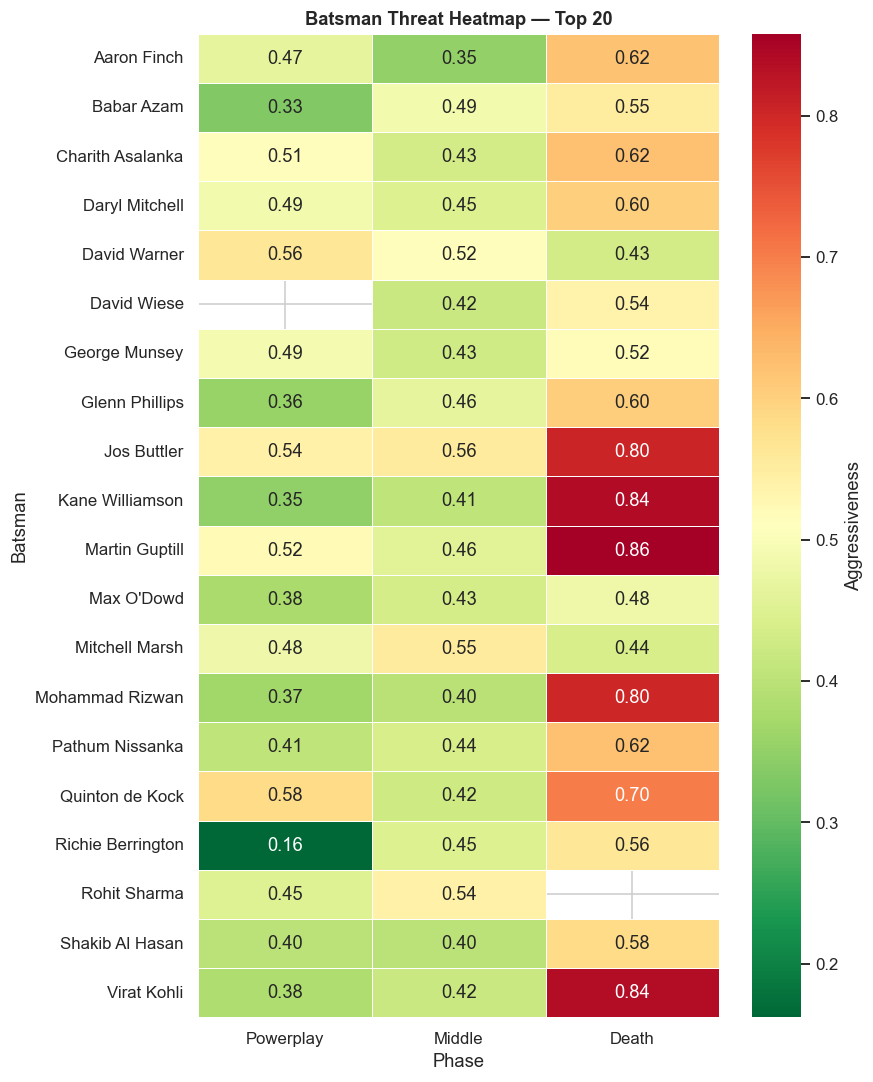

In [19]:
# Threat heatmap top 20 batsmen x phases
top_names = (profiles[profiles['balls_faced']>=100]
             .nlargest(20,'total_runs')['name_key'].tolist())
threat_data = []
for nk in top_names:
    for ph in ['Powerplay','Middle','Death']:
        info = get_batsman_threat(nk, ph)
        if 'error' not in info:
            threat_data.append({'Batsman':info['batsman'],'Phase':ph,
                                 'Aggressiveness':info['aggressiveness'],
                                 'Threat Level':info['threat_level']})
threat_df    = pd.DataFrame(threat_data)
threat_pivot = threat_df.pivot_table('Aggressiveness',index='Batsman',columns='Phase')
threat_pivot = threat_pivot[['Powerplay','Middle','Death']]
plt.figure(figsize=(8,10))
sns.heatmap(threat_pivot,annot=True,fmt='.2f',cmap='RdYlGn_r',linewidths=0.4,
            cbar_kws={'label':'Aggressiveness'})
plt.title('Batsman Threat Heatmap — Top 20',fontweight='bold')
plt.tight_layout(); plt.show()

In [20]:
# Threat distribution pie per phase
tc = threat_df.groupby(['Phase','Threat Level']).size().reset_index(name='count')
fig = px.bar(tc, x='Phase', y='count', color='Threat Level', barmode='group',
             color_discrete_map={'High Threat':'#e74c3c','Medium Threat':'#f39c12','Low Threat':'#2ecc71'},
             category_orders={'Phase':['Powerplay','Middle','Death']},
             title='Threat Distribution by Phase')
fig.show()

In [21]:
# Recommended zone treemap
all_recs = []
for _, row in profiles[profiles['balls_faced']>=50].iterrows():
    for ph in ['Powerplay','Middle','Death']:
        for bstyle in ['right-arm fast','slow left-arm orthodox','right-arm medium-fast']:
            rec = recommend_bowling_strategy(row['Full Name'], ph, bstyle)
            if 'error' not in rec:
                all_recs.append({'Line':rec['recommended_line'],'Length':rec['recommended_length'],'Phase':ph})
rec_df = pd.DataFrame(all_recs)
pivot_rec = rec_df.groupby(['Line','Length']).size().reset_index(name='count')
fig = px.treemap(pivot_rec, path=['Line','Length'], values='count',
                 title='Recommended Pitch Zone Distribution',
                 color='count', color_continuous_scale='Blues')
fig.show()

In [22]:
# Adaptability vs aggressiveness scatter
if len(threat_df) > 0:
    tm = threat_df[threat_df['Phase']=='Middle'].merge(
        profiles[['Full Name','adaptability_index','total_runs']],
        left_on='Batsman',right_on='Full Name',how='left')
    fig = px.scatter(tm, x='adaptability_index', y='Aggressiveness',
                     size='total_runs', color='Threat Level', hover_name='Batsman',
                     color_discrete_map={'High Threat':'#e74c3c','Medium Threat':'#f39c12','Low Threat':'#2ecc71'},
                     title='Adaptability vs Aggressiveness (Middle Overs)',
                     labels={'adaptability_index':'Adaptability Index'})
    fig.show()